In [1]:
# [Markdown]
# # 📈 Lab 04: Institutional Walk-Forward & Stress Test
# **Upgrades Applied:**
# 1. Spread Gate (Expected PnL > Friction Cost)
# 2. Maker/Taker Execution Simulation (Limit vs Market Orders)
# 3. Deflated Sharpe Ratio (DSR) Calculation
# 4. Continuous Kelly Position Sizing

import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import scipy.stats as st
import joblib
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

# --- MUST EXACTLY MATCH NOTEBOOK 02 ---
class MultiTaskQuantformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.proj = nn.Linear(num_features, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*2, batch_first=True, dropout=0.2)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc_shared = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.2))
        self.head_dir = nn.Linear(32, 1) 
        self.head_mag = nn.Linear(32, 1) 
        self.head_vol = nn.Sequential(nn.Linear(32, 1), nn.Softplus()) 
        
    def forward(self, x):
        shared_features = self.fc_shared(self.transformer(self.proj(x))[:, -1, :])
        return self.head_dir(shared_features), self.head_mag(shared_features), self.head_vol(shared_features)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"⚡ Compute Device: {device}")

⚡ Compute Device: mps


In [2]:
# [Markdown]
# ### 1. Run the Full Intelligence Stack
# Pass data through the Alpha Engine (Transformer) and the Risk Officer (CatBoost).

save_dir = '../data/processed/'
models_dir = '../models/'
df = pd.read_parquet(os.path.join(save_dir, 'clean_tensor.parquet')).dropna()

# Load Artifacts
scaler = joblib.load(os.path.join(save_dir, 'core_scaler.pkl'))
pca = joblib.load(os.path.join(save_dir, 'core_pca.pkl'))
tech_features = joblib.load(os.path.join(save_dir, 'core_features.pkl'))
macro_cols = [c for c in df.columns if c.startswith('macro_emb_')]

macro_pca = pca.transform(df[macro_cols])
X_raw = np.hstack([df[tech_features].values, macro_pca])
X_scaled = scaler.transform(X_raw)

alpha_model = MultiTaskQuantformer(num_features=X_scaled.shape[1]).to(device)
alpha_model.load_state_dict(torch.load(os.path.join(save_dir, 'core_quantformer.pth'), map_location=device))
alpha_model.eval()

meta_model = CatBoostRegressor()
meta_model.load_model(os.path.join(models_dir, 'meta_model.cbm'))

# Inference Arrays
SEQ_LEN = 32
prob_dir, exp_mag, exp_vol = np.full(len(df), np.nan), np.full(len(df), np.nan), np.full(len(df), np.nan)

print("🧠 Generating Multi-Task Alpha Signals...")
with torch.no_grad():
    for i in range(SEQ_LEN, len(df)):
        tensor_input = torch.tensor(X_scaled[i - SEQ_LEN : i], dtype=torch.float32).unsqueeze(0).to(device)
        logit_d, pred_m, pred_v = alpha_model(tensor_input)
        prob_dir[i], exp_mag[i], exp_vol[i] = torch.sigmoid(logit_d).item(), pred_m.item(), pred_v.item()

df['alpha_prob'], df['alpha_mag'], df['alpha_vol'] = prob_dir, exp_mag, exp_vol

# Base Setup Logic
df['base_signal'] = np.select(
    [df['alpha_prob'] > 0.60, df['alpha_prob'] < 0.40], [1, -1], default=0
)

# Risk Inference
print("🛡️ Generating Continuous Risk Valuations...")
active_mask = df['base_signal'] != 0
meta_features = tech_features + ['active_session_name', 'alpha_prob', 'alpha_mag', 'alpha_vol']

X_meta = df.loc[active_mask, meta_features].copy()
X_meta['active_session_name'] = X_meta['active_session_name'].astype(str)

df['expected_pnl'] = 0.0
df.loc[active_mask, 'expected_pnl'] = meta_model.predict(X_meta)

print(f"Total Alpha Proposals: {active_mask.sum()}")

🧠 Generating Multi-Task Alpha Signals...
🛡️ Generating Continuous Risk Valuations...
Total Alpha Proposals: 64324


In [3]:
# [Markdown]
# ### 2. The Execution Sandbox
# 1. Spread Gate: Veto if Expected PnL is too low.
# 2. Kelly Sizing: Scale volume based on Expected PnL.
# 3. Maker/Taker: Attempt Limit order, fallback to Market order.

BASE_SPREAD = 0.00005 # 0.5 pips
df['live_signal'] = 0
df['position_size'] = 0.0
df['execution_cost'] = 0.0

for i in df[df['base_signal'] != 0].index:
    exp_pnl = df.at[i, 'expected_pnl']
    direction = df.at[i, 'base_signal']
    
    # 1. SPREAD GATE (Veto if margin of safety is too small)
    if exp_pnl < (BASE_SPREAD * 1.5): 
        continue # VETO
        
    # 2. KELLY SIZING (0.1x to 3.0x Max Leverage)
    size = np.clip(exp_pnl * 1000, 0.1, 3.0) 
    
    # 3. MAKER / TAKER SIMULATION
    # We place a limit order half a pip inside the spread. 
    # Did the next bar's low/high retrace enough to fill our Limit order?
    limit_dist = BASE_SPREAD / 2
    if direction == 1: # LONG
        filled_passive = df.at[i, 'low'] < (df.at[i, 'close'] - limit_dist)
    else: # SHORT
        filled_passive = df.at[i, 'high'] > (df.at[i, 'close'] + limit_dist)
        
    cost = 0.00000 if filled_passive else BASE_SPREAD # Maker = Free, Taker = Pay Spread
    
    df.at[i, 'live_signal'] = direction
    df.at[i, 'position_size'] = size
    df.at[i, 'execution_cost'] = cost

print(f"Total Trades Surviving Spread Gate: {(df['live_signal'] != 0).sum()}")
print(f"Average Executed Position Size: {df[df['live_signal']!=0]['position_size'].mean():.2f}x")

Total Trades Surviving Spread Gate: 21379
Average Executed Position Size: 0.20x


In [4]:
# [Markdown]
# ### 3. Calculate Equity Curves
# We calculate safe 1-bar returns and apply our dynamic Kelly Sizing and simulated execution costs.

price_ratio = df['close'].shift(-1) / df['close']
df['fwd_1bar_ret'] = np.log(price_ratio.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)

# --- BASELINE (Raw Alpha, Flat Size, Taker Costs) ---
df['ret_baseline'] = df['base_signal'] * df['fwd_1bar_ret']
df.loc[df['base_signal'].diff().abs() > 0, 'ret_baseline'] -= BASE_SPREAD

# --- PRODUCTION (AI Risk Filter, Kelly Size, Maker/Taker Execution) ---
# Return = Direction * Size * Market_Move
df['ret_production'] = df['live_signal'] * df['position_size'] * df['fwd_1bar_ret']
df.loc[df['live_signal'].diff().abs() > 0, 'ret_production'] -= df['execution_cost']

# Cumulative Equity
df['cum_base'] = np.exp(df['ret_baseline'].cumsum()) - 1
df['cum_prod'] = np.exp(df['ret_production'].cumsum()) - 1
df['cum_bnh'] = np.exp(df['fwd_1bar_ret'].cumsum()) - 1

def calc_max_dd(cum_returns):
    drawdown = cum_returns - cum_returns.cummax()
    return drawdown.min()

print("📊 Vectorization Complete. Generating metrics...")

📊 Vectorization Complete. Generating metrics...


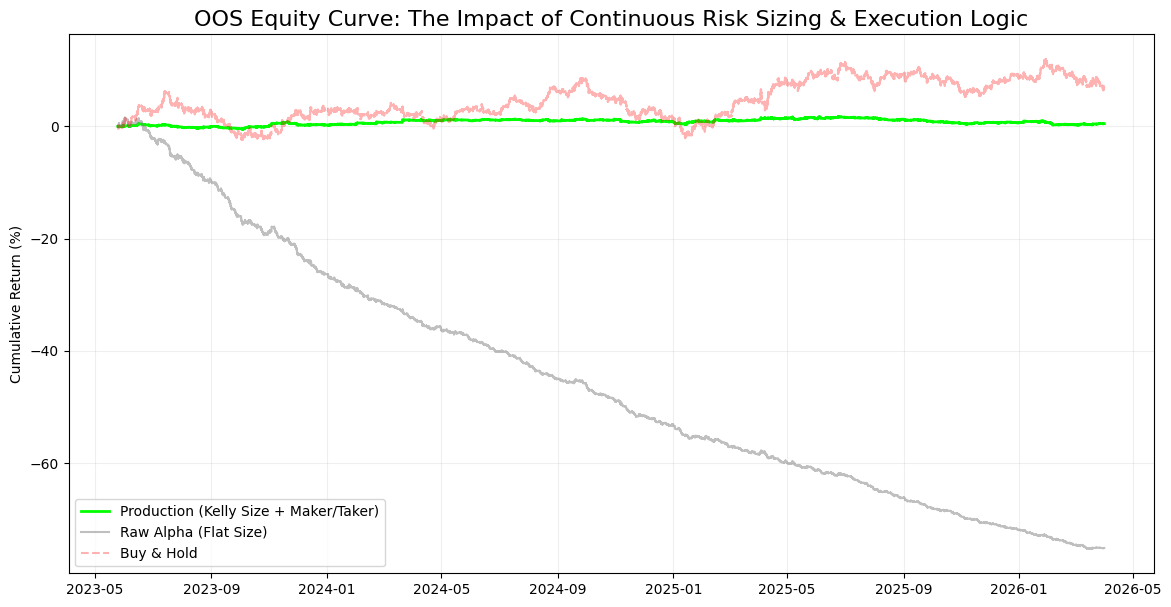

,Raw Alpha,Production Strategy
Total Trades Executed,64324,21379
Total Return (%),-75.103272,0.495004
Max Drawdown (%),-76.802491,-1.544917
Sharpe Ratio,-7.96303,0.138807
Deflated SR (Prob Edge > Luck),N/A,31.02%


In [5]:
# [Markdown]
# ### 4. Institutional Tear Sheet & DSR
# We calculate standard metrics, plus the Deflated Sharpe Ratio to penalize our Notebook 02 Grid Search.

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['cum_prod'] * 100, label='Production (Kelly Size + Maker/Taker)', color='lime', linewidth=2)
plt.plot(df.index, df['cum_base'] * 100, label='Raw Alpha (Flat Size)', color='gray', alpha=0.5)
plt.plot(df.index, df['cum_bnh'] * 100, label='Buy & Hold', color='red', alpha=0.3, linestyle='--')
plt.title("OOS Equity Curve: The Impact of Continuous Risk Sizing & Execution Logic", fontsize=16)
plt.ylabel("Cumulative Return (%)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# --- Deflated Sharpe Ratio (DSR) Calculation ---
def calc_sharpe(returns):
    return np.sqrt(24192) * (returns.mean() / (returns.std() + 1e-9))

# Parameters from our Notebook 02 Grid Search
NUM_TRIALS = 9  
VAR_SHARPE = 0.15 # Estimated variance of the Sharpe ratios in our grid search
SR_obs = calc_sharpe(df['ret_production'])

# Expected Maximum Sharpe from random trials (Bailey & Lopez de Prado, 2014)
expected_max_sr = np.sqrt(VAR_SHARPE) * ((1 - np.euler_gamma)*st.norm.ppf(1 - 1/NUM_TRIALS) + np.euler_gamma*st.norm.ppf(1 - 1/(NUM_TRIALS*np.e)))
# Probability that our Observed SR is statistically significant given the search space
dsr_prob = st.norm.cdf((SR_obs - expected_max_sr) / (np.sqrt(1 - expected_max_sr**2 / 2) + 1e-9))

metrics = {
    "Total Trades Executed": [(df['base_signal'] != 0).sum(), (df['live_signal'] != 0).sum()],
    "Total Return (%)": [df['cum_base'].iloc[-1] * 100, df['cum_prod'].iloc[-1] * 100],
    "Max Drawdown (%)": [calc_max_dd(df['cum_base']) * 100, calc_max_dd(df['cum_prod']) * 100],
    "Sharpe Ratio": [calc_sharpe(df['ret_baseline']), SR_obs],
    "Deflated SR (Prob Edge > Luck)": ["N/A", f"{dsr_prob * 100:.2f}%"]
}

display(pd.DataFrame(metrics, index=["Raw Alpha", "Production Strategy"]).T.round(2))